In [1]:
%load_ext autoreload
%autoreload 2

# Segway model with Rolling Resistance

After comparing the real world data and the simulated data, we found that the actual segway seems to have a non-negligible rolling resistance, which the difference can be approximated by the rolling friction force. (According to mojuco document [here](https://mujoco.readthedocs.io/en/latest/XMLreference.html?utm_source=chatgpt.com#body-geom-friction))

## Rolling Resistance



Accoring to mojuco document, we will use the convension that the rolling resistance is a constant torque. The rolling resistance torque is calculated as:

$$
\tau_{rolling} = -\mu_{rolling} \cdot N
$$

It will act as a generialized torque in the langrangian dynamics:

$$
\begin{aligned}
\tau_{rolling} &= -\mu_{rolling} \cdot N  \\
&= -\mu_{rolling} \cdot m \cdot g  \\
&= -\mu_{rolling} \cdot m \cdot g  \cdot \text{sign}(\dot{\theta})
\end{aligned}
$$

Now we already got the model:

$$
\begin{align}
 (m + m_w ) \ddot{x}_C + m h \ddot{\gamma} \cos \gamma - m h \dot{\gamma}^2 \sin \gamma &= \frac{(M - T_{damp})}{R} , \\
m h \ddot{x}_C \cos \gamma + (m h^2 + I) \ddot{\gamma} - m g h \sin \gamma &= - (M - T_{damp}).
\end{align}
$$

Consider the portion of the virtual work done by the rolling resistance torque: 
$$\begin{aligned}
\delta W &= \tau_{rolling} \cdot \delta \varphi \\
&= \tau_{rolling} \cdot \frac{\delta x_C}{R} \\
\end{aligned}   
$$

The final model with rolling resistance is:
$$
\begin{align}
 (m + m_w ) \ddot{x}_C + m h \ddot{\gamma} \cos \gamma - m h \dot{\gamma}^2 \sin \gamma &= \frac{(M - T_{damp})}{R} + \tau_{rolling} \cdot \frac{1}{r} = \frac{(M - T_{damp})}{R} - \mu_{rolling} \cdot (m + m_w) \cdot g \cdot  \text{sign}(\dot{x_c}) /R, \\
m h \ddot{x}_C \cos \gamma + (m h^2 + I) \ddot{\gamma} - m g h \sin \gamma &= - (M - T_{damp}).
\end{align}
$$

## Model derivation with rolling resistance

To save some trouble, we can compare the result of the motor damping model here to derive the model with rolling resistance.

The solution for the motor damping model is:

$$
\begin{align}\ddot{x} &= N_{11} \left(\frac{(M - T_{damp})}{R} + m h \dot{\gamma}^2 \sin \gamma\right) + N_{12} \left(-(M - T_{damp}) + m g h \sin \gamma\right), \\
\ddot{\gamma} &= N_{21} \left(\frac{(M - T_{damp})}{R} + m h \dot{\gamma}^2 \sin \gamma\right) + N_{22} \left(-(M - T_{damp}) + m g h \sin \gamma\right).
\end{align}
$$

Where:
$$
\begin{align}
N(q) = \begin{bmatrix}m + m_w & m h \cos \gamma \\
m h \cos \gamma & m h^2\end{bmatrix}^{-1}. \\
T_{damp} = B \omega + B_0 sign(\omega) = B \left(\frac{\dot{x}_C}{R} -\dot{\gamma}\right) + B_0 sign\left(\frac{\dot{x}_C}{R} -\dot{\gamma}\right).
\end{align}
$$

Thus the solution for the model with rolling resistance is:
$$
\begin{align}\ddot{x} &= N_{11} \left(\frac{(M - T_{damp})}{R} - \mu_{rolling} \cdot (m + m_w) \cdot g \cdot \text{sign}(\dot{x}_C) / R + m h \dot{\gamma}^2 \sin \gamma\right) + N_{12} \left(-(M - T_{damp}) + m g h \sin \gamma\right), \\
\ddot{\gamma} &= N_{21} \left(\frac{(M - T_{damp})}{R} - \mu_{rolling} \cdot (m + m_w) \cdot g \cdot \text{sign}(\dot{x}_C) / R + m h \dot{\gamma}^2 \sin \gamma\right) + N_{22} \left(-(M - T_{damp}) + m g h \sin \gamma\right).
\end{align}
$$

Where:
$$
\begin{align}
N(q) = \begin{bmatrix}m + m_w & m h \cos \gamma \\
m h \cos \gamma & m h^2 + I\end{bmatrix}^{-1}. \\
T_{damp} = B \omega + B_0 sign(\omega) = B \left(\frac{\dot{x}_C}{R} -\dot{\gamma}\right) + B_0 sign\left(\frac{\dot{x}_C}{R} -\dot{\gamma}\right).
\end{align}
$$

# Simulation result

- Velocity mode:

Rolling Resistance: 0.0000 N
Rolling Resistance: -0.0000 N
Rolling Resistance: -0.0001 N
Rolling Resistance: -0.0001 N
Rolling Resistance: -0.0003 N
Rolling Resistance: -0.0004 N
Rolling Resistance: -0.0004 N
Rolling Resistance: -0.0004 N
Rolling Resistance: -0.0013 N
Rolling Resistance: -0.0017 N
Rolling Resistance: -0.0037 N
Rolling Resistance: -0.0040 N
Rolling Resistance: -0.0045 N
Rolling Resistance: -0.0045 N
Rolling Resistance: -0.0120 N
Rolling Resistance: -0.0148 N
Rolling Resistance: -0.0295 N
Rolling Resistance: -0.0336 N
Rolling Resistance: -0.0360 N
Rolling Resistance: -0.0332 N
Rolling Resistance: -0.0391 N
Rolling Resistance: -0.0410 N
Rolling Resistance: -0.0520 N
Rolling Resistance: -0.0564 N
Rolling Resistance: -0.0580 N
Rolling Resistance: -0.0535 N
Rolling Resistance: -0.0569 N
Rolling Resistance: -0.0578 N
Rolling Resistance: -0.0639 N
Rolling Resistance: -0.0681 N
Rolling Resistance: -0.0688 N
Rolling Resistance: -0.0634 N
Rolling Resistance: -0.0646 N
Rolling Res

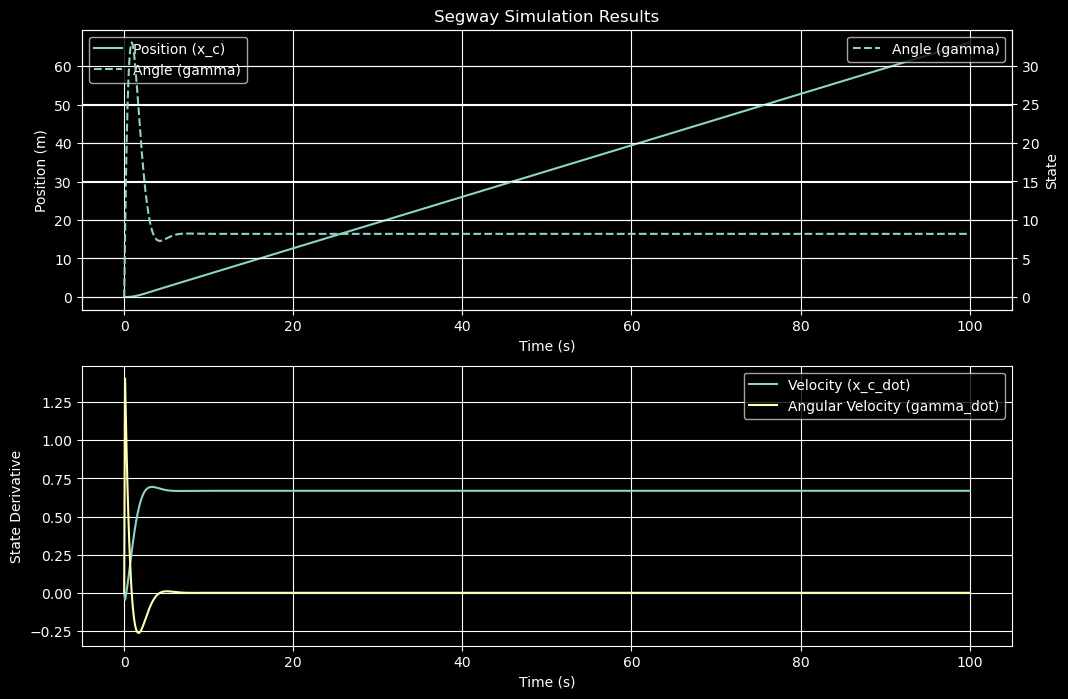

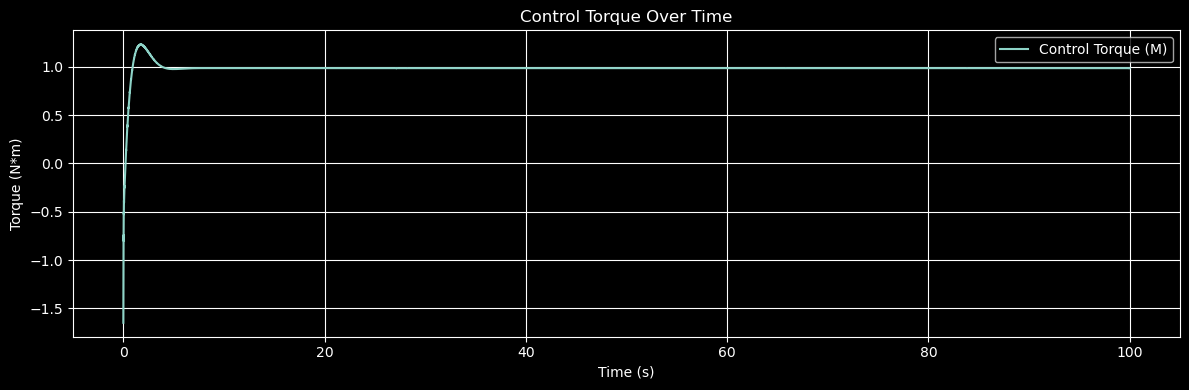

In [ ]:
from Runner import run_simulation
from Parameters import params
from Config import CONTROL_MODE, MODEL_T, CONTROL_STRATEGY

params.mu_rolling = 0.005
params.smooth_factor = 100

run_simulation(
    initial_state=[0.0, 0.0, 0.0, 0.0],
    time_span=(0, 100),
    control_mode=CONTROL_MODE.VELOCITY,
    controller_type=CONTROL_STRATEGY.PD,
    desired_gamma=0.0,
    desired_velocity=0.5,
    desired_position=0.0,
    model_type=MODEL_T.ROLLING_RESISTANCE,
    record_Torque=True,
    export_CSV_flag=True,
)

- Position mode:

Rolling Resistance: 0.0000 N
Rolling Resistance: -0.0000 N
Rolling Resistance: -0.0000 N
Rolling Resistance: -0.0000 N
Rolling Resistance: -0.0001 N
Rolling Resistance: -0.0001 N
Rolling Resistance: -0.0001 N
Rolling Resistance: -0.0001 N
Rolling Resistance: -0.0003 N
Rolling Resistance: -0.0004 N
Rolling Resistance: -0.0009 N
Rolling Resistance: -0.0010 N
Rolling Resistance: -0.0011 N
Rolling Resistance: -0.0011 N
Rolling Resistance: -0.0030 N
Rolling Resistance: -0.0037 N
Rolling Resistance: -0.0073 N
Rolling Resistance: -0.0083 N
Rolling Resistance: -0.0089 N
Rolling Resistance: -0.0083 N
Rolling Resistance: -0.0098 N
Rolling Resistance: -0.0102 N
Rolling Resistance: -0.0131 N
Rolling Resistance: -0.0142 N
Rolling Resistance: -0.0146 N
Rolling Resistance: -0.0135 N
Rolling Resistance: -0.0144 N
Rolling Resistance: -0.0146 N
Rolling Resistance: -0.0162 N
Rolling Resistance: -0.0173 N
Rolling Resistance: -0.0175 N
Rolling Resistance: -0.0161 N
Rolling Resistance: -0.0164 N
Rolling Res

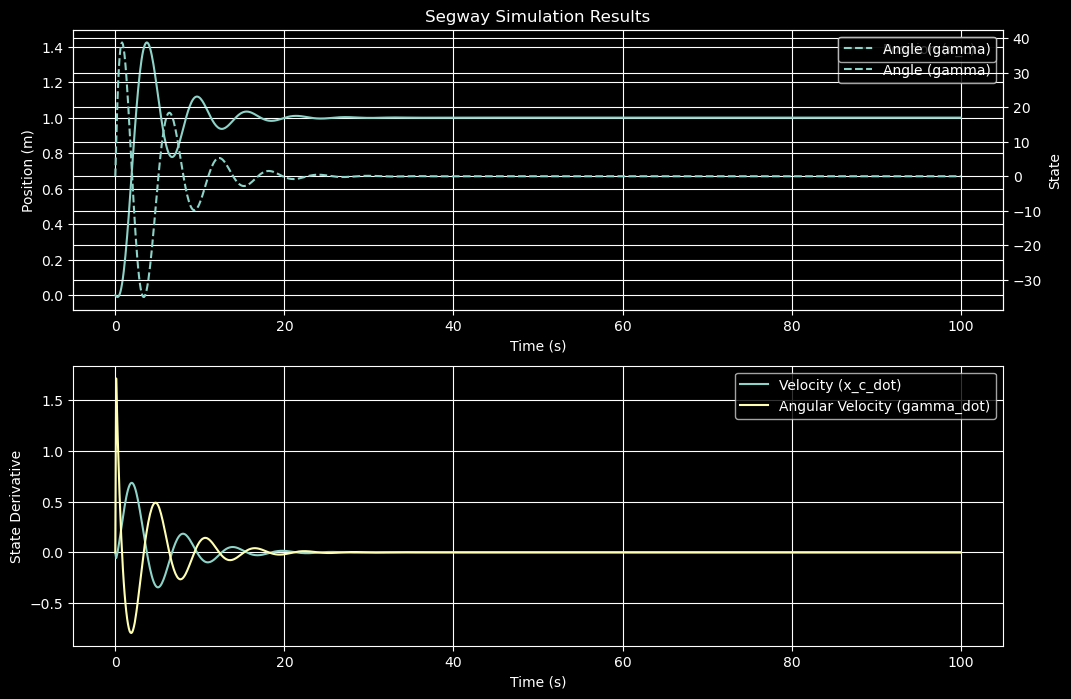

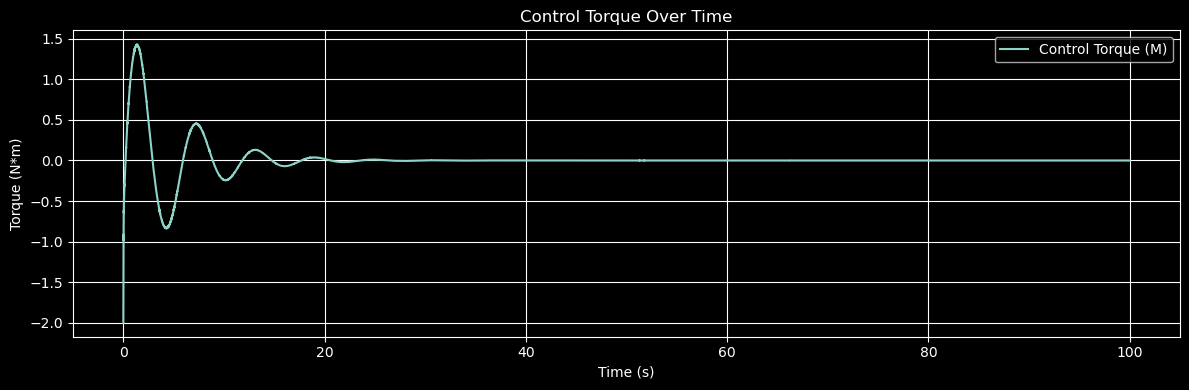

In [1]:
import Runner
import Parameters
from Config import CONTROL_MODE, MODEL_T, CONTROL_STRATEGY

Parameters.params.mu_rolling = 0.005

Runner.run_simulation(
    initial_state=[0.0, 0.0, 0.0, 0.0],
    time_span=(0, 100),
    control_mode=CONTROL_MODE.POSITION,
    controller_type=CONTROL_STRATEGY.PD,
    desired_gamma=0.0,
    desired_velocity=0.0,
    desired_position=1.0,
    model_type=MODEL_T.ROLLING_RESISTANCE,
    record_Torque=True,
    export_CSV_flag=True,
)